# 7. Predicting with Tabular Data

Most datasets won't come as images, text, or even sound data. The most common format of data today is tabular data, since most databases are made of relational ables. These tables will be the main source of tabular data.

There are certain challenges faced by Deep Neural Networks when applied to tabular data:

1. Mixed feature data types
2. Data in sparse formats - more zeroes than non-zeroes, not good for convergence in DNN for an optimal solution
3. No state-of-the-art architecture, just some best practices
4. Less data is available for a single specific problem
5. Less interpretable model (DNN) as compared to conventional ML algorithms when applied to tabular data
6. DNNs might not be the best solution (consider gradient boosting solutions e.g `LightGBM`, `XGBoost`, `CatBoost`)

__scikit-learn__ is useful for comparing the performance of different algorithms on a problem, and if you need a standardized data preparation pipeline for algorithms from differnet packages

## 7a. Processing Numerical Data

Numerical Data:

* Data is expressed by a floating point number
* Data is an integer and it has certain number of unique values
* Data is an integer and not represeting a class or label

With numerical data, some situations may affect the performance of DNNs:

1. Missing data (Null, NaN or INF values)
2. Constant values might make computations slower or interfere with bias in each neuron
3. Skewed distributions
4. Non-standardized data, especially data with extreme values

Ensure that these issues are dealt with prior to feeding the data into the DNN

Example: build a scikit-learn pipeline based on indications relative to:

* __Minimum variance__ for a feature to be kept - else will just introduce unwanted constants into network
* What strategy to use when __handling missing data__, ensures that matric is completed for matrix multiplication to occur - `imputer` will default to using the mean of the variable
* Whether or not to use more __sophisticated imputation__ strategies for missing values
* Whether to add a feature to __indicate where the missing values are__ - occassionally a good strategy if the missing values actually form a pattern to explain why they are missing
* Whether to transform the distribution of data to resemble a __common/symmetric distribution__ - because networks learn better from known distributions
* Whether we should __normalize__ or standardize the variables 

In [1]:
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline

# Sample data
example = pd.DataFrame([[1, 2, 3, np.nan], [1, 3, np.nan, 4], [1, 2, 2, 2]], columns = ['a', 'b', 'c', 'd'])

In [2]:
# Build the pipeline
def assemble_numeric_pipeline(variance_threshold=0.0, imputer='mean', multivariate_imputer=False, add_indicator=True, quantile_transformer='normal', scaler=True):
  numeric_pipeline = []
  if variance_threshold is not None:
    if isinstance(variance_threshold, float):
      numeric_pipeline.append(('var_filter', VarianceThreshold(threshold=variance_threshold)))
    else:
      numeric_pipeline.append(('var_filter', VarianceThreshold()))
  
  if imputer is not None:
    if multivariate_imputer is True:
      numeric_pipeline.append(('imputer', 
                               IterativeImputer(estimator=ExtraTreesRegressor(n_estimators=100, n_jobs=-2), 
                                                      initial_strategy=imputer,
                                                      add_indicator=add_indicator)))
    else:
      numeric_pipeline.append(('imputer',
                               SimpleImputer(
                                 strategy=imputer,
                                 add_indicator=add_indicator
                               )))
  
  if quantile_transformer is not None:
    numeric_pipeline.append(('transformer', 
                             QuantileTransformer(n_quantiles=100, 
                                                     output_distribution=quantile_transformer, 
                                                     random_state=42)))
  
  if scaler is not None:
    numeric_pipeline.append(('scaler', 
                             StandardScaler()))
  
  return Pipeline(steps=numeric_pipeline)

__Note: Preprocessing pipelines steps have the following structure__

`('step_name', Some_Processing_Function(parameters))` as tuples

In [3]:
# Create numerical pipeline
numeric_pipeline = assemble_numeric_pipeline(variance_threshold=0.0, 
                              imputer='mean', 
                              multivariate_imputer=False, 
                              add_indicator=True,
                              quantile_transformer='normal',
                              scaler=True)

# Apply on the example data
# 	- first .fit() then .transform()
numeric_pipeline.fit(example)
np.round(numeric_pipeline.transform(example), 3)

c:\Users\Martin Ho\Languages\python38\lib\site-packages\sklearn\preprocessing\_data.py:2367: UserWarning: n_quantiles (100) is greater than the total number of samples (3). n_quantiles is set to n_samples.
  warnings.warn("n_quantiles (%s) is greater than the total number "


array([[-0.707,  1.225, -0.   , -0.707,  1.414],
       [ 1.414, -0.   ,  1.225,  1.414, -0.707],
       [-0.707, -1.225, -1.225, -0.707, -0.707]])

__Summary__

Important to define the specific processes for training and testing data. For images, the preprocessing transformations are deterministic (e.g rotating and image by 90 degrees), but for tabular data transformations are more complex and depend on the data that is available in that column/table (e.g the mean used to standardize or impute data will change depending on the column or data it is fitted on)

Changes to the process will affect the DNN performance, since the model is fitted to the original data.

In [4]:
# Understanding what was done to the sample data
def derive_numeric_columns(df, pipeline):
  columns = df.columns
  if 'var_filter' in pipeline.named_steps:
    threshold = pipeline.named_steps.var_filter.threshold
    columns = columns[pipeline.named_steps.var_filter.variances_ > threshold]
  if 'imputer' in pipeline.named_steps:
    missing_cols = pipeline.named_steps.imputer.indicator_.features_
    if len(missing_cols) > 0:
      columns = columns.append(columns[missing_cols] + "_missing")
  return columns

derive_numeric_columns(example, numeric_pipeline)

Index(['b', 'c', 'd', 'c_missing', 'd_missing'], dtype='object')

Notice that since column 'a' was basically `[1, 1, 1]` it failed the variance threshold and was removed. Each of the subsequent columns are added based on the missing variable indicator from the imputer

---

## 7b. Processing Dates

Dates are common in databases, especially when processing the forecasting of future estimates, can be valuable.

Consider the following:

* Dates alone cannot be processed since they are strings, therefore, split them into their numerical components
* Some time elements are cyclical and can be contiguous - use sine and cosine functions to change the format to be correctly interpreted by the model

Use the `BaseEstimator` and `TransformerMixin` classes to inherit and implement our own fit and transform

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin

example_dates = pd.DataFrame({'date_1': ['04/12/2018', '05/12/2019', '07/12/2020'],
                        'date_2': ['12/5/2018', '15/5/2015', '18/5/2016'],
                        'date_3': ['25/8/2019', '28/8/2018', '29/8/2017']})

In [6]:
# Class that will extract individual date components and apply sine and cosine transformations
class DateProcessor(BaseEstimator, TransformerMixin):
  def __init__(self, date_format='%d/%m/%Y', hours_secs=False):
    self.format = date_format
    self.columns = None
    self.time_transformations = [
      ('day_sin', lambda x: np.sin(2*np.pi*x.dt.day/31)),
      ('day_cos', lambda x: np.cos(2*np.pi*x.dt.day/31)),
      ('dayofweek_sin', lambda x: np.sin(2*np.pi*x.dt.dayofweek/6)),
      ('dayofweek_cos', lambda x: np.cos(2*np.pi*x.dt.dayofweek/6)),
      ('month_sin', lambda x: np.sin(2*np.pi*x.dt.month/12)),
      ('month_cos', lambda x: np.cos(2*np.pi*x.dt.month/12)),
      ('year', lambda x: (x.dt.year - x.dt.year.min()) / (x.dt.year.max() - x.dt.year.min()))
    ]
    if hours_secs:
      self.time_transformations = [
        ('hour_sin', lambda x: np.sin(2*np.pi*x.dt.hour/23)),
        ('hour_cos', lambda x: np.cos(2*np.pi*x.dt.hour/23)),
        ('minute_sin', lambda x: np.sin(2*np.pi*x.dt.minute/59)),
        ('minute_cos', lambda x: np.cos(2*np.pi*x.dt.minute/59))
      ] + self.time_transformations
      
  def fit(self, X, y=None, **fit_params):
   self.columns = self.transform(X.iloc[0:1,:]).columns
   return self
 
  def transform(self, X, y=None, **fit_params):
    transformed = []
    for col in X.columns:
      time_column = pd.to_datetime(X[col], format=self.format)
      for label, func in self.time_transformations:
        transformed.append(func(time_column))
        transformed[-1].name = transformed[-1].name + "_" + label
    transformed = pd.concat(transformed, axis=1)
    return transformed
  
  def fit_transform(self, X, y=None, **fit_params):
    self.fit(X, y, **fit_params)
    return self.transform(X) 

In [7]:
DateProcessor().fit_transform(example_dates)

,date_1_day_sin,date_1_day_cos,date_1_dayofweek_sin,date_1_dayofweek_cos,date_1_month_sin,date_1_month_cos,date_1_year,date_2_day_sin,date_2_day_cos,date_2_dayofweek_sin,...,date_2_month_sin,date_2_month_cos,date_2_year,date_3_day_sin,date_3_day_cos,date_3_dayofweek_sin,date_3_dayofweek_cos,date_3_month_sin,date_3_month_cos,date_3_year
0,0.724793,0.688967,8.660254e-01,0.5,-2.449294e-16,1.0,0.0,0.651372,-0.758758,-0.866025,...,0.5,-0.866025,1.000000,-0.937752,0.347305,-2.449294e-16,1.0,-0.866025,-0.5,1.0
1,0.848644,0.528964,1.224647e-16,-1.0,-2.449294e-16,1.0,0.5,0.101168,-0.994869,-0.866025,...,0.5,-0.866025,0.000000,-0.571268,0.820763,8.660254e-01,0.5,-0.866025,-0.5,0.5
2,0.988468,0.151428,0.000000e+00,1.0,-2.449294e-16,1.0,1.0,-0.485302,-0.874347,0.866025,...,0.5,-0.866025,0.333333,-0.394356,0.918958,8.660254e-01,0.5,-0.866025,-0.5,0.0


### How it works

Algorithm doesn't return the raw extraction of the elements of time, but transforms them using a sine an cosine transformation. Below shows how it transforms the 24 hours. By using a combination of both sine and cosine, it will help to create a _2D map_ of how time should be repsented, so that same value time value (11:00 and 23:00) won't return the same value

Learn more from: https://towardsdatascience.com/cyclical-features-encoding-its-about-time-ce23581845ca?gi=fbd53db38d1a

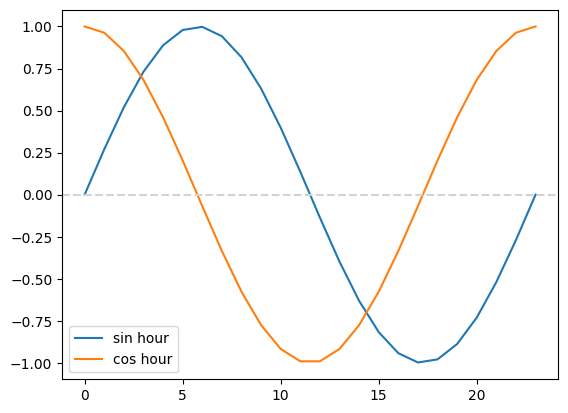

In [8]:
import matplotlib.pyplot as plt

sin_time = np.array([[t, np.sin(2*np.pi*t/23)] for t in range(0, 24)])
cos_time = np.array([[t, np.cos(2*np.pi*t/23)] for t in range(0, 24)])

plt.plot(sin_time[:,0], sin_time[:,1], label='sin hour')
plt.plot(cos_time[:,0], cos_time[:,1], label='cos hour')
plt.axhline(y=0.0, linestyle='--', color='lightgray')
plt.legend()
plt.show()

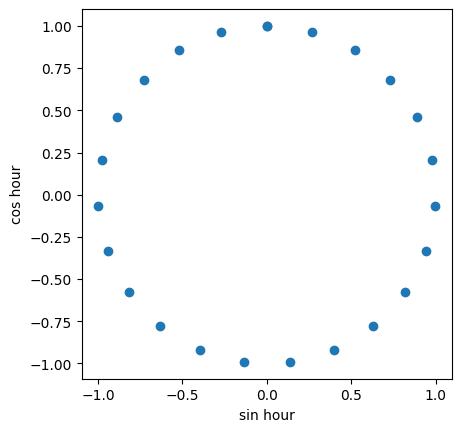

In [9]:
# Visually how sine and cosine work together
ax = plt.subplot()
ax.set_aspect('equal')
ax.set_xlabel('sin hour')
ax.set_ylabel('cos hour')
plt.scatter(sin_time[:,1], cos_time[:,1])
plt.show()

---

## 7c. Processing Categorical Data

In statistical terms, each unique value is called a _level_ and the categorical feature is called a factor. Categorical features are usually represented as strings, each with some unique values. Occassionally, some categorical features already have identifiers which are qualitative features encoded into numbers, processing them works the same way.

Might not know how each unique value in a categorical feature is related, so by transforming them into numerical values, a hypothesis is inherently made about the feature.

__One-hot encoding__ - process of turning each unique categorical variable into individual columns indicating the presence of the corresponding value in the data entry. Can potentially make dataset huge, but also carry little information, making data sparse.

__Cardinality__ - Number of unique items in a set. Low cardinality variables are good for one-hot encoding, while the opposite is not. Usually threshold is <255 unique values, but a lower threshold can be set

In [10]:
from sklearn.preprocessing import OneHotEncoder

# Sample data
example = pd.DataFrame([['car', 1234], ['house', 6543], ['tree', 3456]], columns=['object', 'code'])

# Create class that changes numbers to strings
class ToString(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None, **fit_params):
    return self
  
  def transform(self, X, y=None, **fit_params):
    return X.astype(str)
  
  def fit_transform(self, X, y=None, **fit_params):
    self.fit(X, y, **fit_params)
    return self.transform(X)

# Pipeline that includes a one-hot encoder
categorical_pipeline = Pipeline(steps=[
	('string_converter', ToString()),
	('imputer', SimpleImputer(strategy='constant',
                           fill_value='missing')),
	('onehot', OneHotEncoder(handle_unknown='ignore'))
])

categorical_pipeline.fit_transform(example).todense()

matrix([[1., 0., 0., 1., 0., 0.],
        [0., 1., 0., 0., 0., 1.],
        [0., 0., 1., 0., 1., 0.]])

In [11]:
# Extract the labels for ohe columns
def derive_ohe_columns(df, pipeline):
  return [str(col) + '_' + str(lvl) for col, lvls in zip(df.columns, pipeline.named_steps.onehot.categories_) for lvl in lvls]

derive_ohe_columns(example, categorical_pipeline)

['object_car',
 'object_house',
 'object_tree',
 'code_1234',
 'code_3456',
 'code_6543']

__Summary__

Provides an indication of both the original feature and the unique represented binary variable

---

## 7d. Processing Ordinal Data

Ordinal data is ranking data, where the order is incorporated in the numerical value. By treating them solely as categorical data, some information is lost in the ordering. The distance between some orders might not be the same as others also, which can also lead to some information loss.

The solution is to treat it both as a numerical and categorical variable

In [12]:
from sklearn.preprocessing import OrdinalEncoder

# Example data
example = pd.DataFrame([['first', 'very much'],
                        ['second', 'very little'],
                        ['third', 'average']],
                       columns=['rank', 'importance'])

Prepare 2 pipelines:

1. Turn ordinal fata into ordered numeric - preserve the ordering of the original feature
2. One-hot encode the ordinal data - preseve the step information between ordinal grades, but not ordering 

2 information should be able to capture the gist of ordinal data

In [13]:
# Ordinal encoder preserves the order between the values
oe = OrdinalEncoder(categories=[['first', 'second', 'third'],
                                ['very much', 'average', 'very little']])

# Categorical encoder preserves the step information between the values
categorical_pipeline = Pipeline(steps=[
	('string_converter', ToString()),
	('imputer', SimpleImputer(strategy='constant',
                           fill_value='missing')),
	('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Apply both pipelines to the data
print(np.hstack((oe.fit_transform(example), categorical_pipeline.fit_transform((example)).todense())))

# Add the columns 
example.columns.tolist() + derive_ohe_columns(example, categorical_pipeline)

[[0. 0. 1. 0. 0. 0. 0. 1.]
 [1. 2. 0. 1. 0. 0. 1. 0.]
 [2. 1. 0. 0. 1. 1. 0. 0.]]


['rank',
 'importance',
 'rank_first',
 'rank_second',
 'rank_third',
 'importance_average',
 'importance_very little',
 'importance_very much']

__Summary__

By combining variables covering the numerical part and the unique values of ordinal variable, the combination of these 2 extractions of the orginal ordinal data is able to capture most of the information

---

## 7e. Processing High-cardinality Categorical Data

One-hot encoding will produce a sparse matrix, which might cause convergence issues when using a neural network.

A solution is to pass them to the neural network as numerically labeled features and let the embedding layers process them. 

__Embedding layers__ - matrix of weights that help convert high-cardinality categorical inputs into lower dimensions. Weighted linear combination of weights are optmized to convert categorical data into numbers.

This process only works on numerically labelled categories (not strings), so must feed in only the right type of data

In [14]:
from sklearn.preprocessing import LabelEncoder
import string
import random
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

# Generator for high-cardinality data
def random_id(length=8):
  voc = string.ascii_lowercase + string.digits
  return ''.join(random.choice(voc) for i in range(length))

example = pd.DataFrame({'high_cat_1': [random_id(length=2) for i in range(500)],
                        'high_cat_2': [random_id(length=3) for i in range(500)],
                        'high_cat_3': [random_id(length=4) for i in range(500)]
                        })

example											


,high_cat_1,high_cat_2,high_cat_3
0,xn,g2a,3pt5
1,cx,3cz,fk7f
2,o5,1m1,4p4o
3,bt,jw8,tmu6
4,mz,3tv,8ogq
...,...,...,...
495,68,xob,r6st
496,3z,rkw,pwm0
497,t7,3qw,9gfb
498,qe,5s1,4h4s


In [15]:
# Original LabelEncoder is unable to handle unseen categories and missing data, so augment the following
# 	- automatically handle missing data
# 	- keeps records of mappings between original categorical values and numeric equivalent
# 	- handle unseen categories, labelled as 'unknown'
class LEncoder(BaseEstimator, TransformerMixin):
  
  def __init__(self):
    self.encoders = {}
    self.dictionary_size = []
    self.unk = 1
  
  def fit(self, X, y=None, **fit_params):
    for col in range(X.shape[1]):
      le = LabelEncoder()
      le.fit(X.iloc[:, col].fillna('_nan'))
      le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    
      if '_nan' not in le_dict:
        max_value = max(le_dict.values())
        le_dict['_nan'] = max_value
      
      max_value = max(le_dict.values())
      le_dict['_unk'] = max_value
      
      self.unk = max_value
      self.dictionary_size.append(len(le_dict))
      col_name = X.columns[col]
      self.encoders[col_name] = le_dict
  
    return self
  
  def transform(self, X, y=None, **fit_params):
    output = []
    for col in range(X.shape[1]):
      col_name = X.columns[col]
      le_dict = self.encoders[col_name]
      emb = X.iloc[:, col].fillna('_nan').apply(lambda x: le_dict.get(x, le_dict['_unk'])).values
      output.append(pd.Series(emb,
                              name=col_name).astype(np.int32))
    
    return output
  
  def fit_transform(self, X, y=None, **fit_params):
    self.fit(X, y, **fit_params)
    return self.transform(X)

In [16]:
# Fit and transform
le = LEncoder()
le.fit_transform(example)

[0      385
 1      144
 2      280
 3      130
 4      265
       ... 
 495     71
 496     45
 497    337
 498    308
 499     48
 Name: high_cat_1, Length: 500, dtype: int32,
 0      215
 1       40
 2       20
 3      262
 4       46
       ... 
 495    468
 496    372
 497     44
 498     72
 499    252
 Name: high_cat_2, Length: 500, dtype: int32,
 0       57
 1      225
 2       68
 3      418
 4      131
       ... 
 495    377
 496    363
 497    140
 498     66
 499    125
 Name: high_cat_3, Length: 500, dtype: int32]

For the embedding layer to work, the input size of each categorical variable must be specified. In this case we can access the number of unique values through the `le.dictionary_size` method. `[413, 498, 502]`. This includes the missing and unknown labels

In [17]:
le.encoders
le.dictionary_size


[413, 501, 502]

---

## 7f. Putting it Together

Use `FeatureUnion` function to combine multiple transformations together and concatenate them easily

In [18]:
from sklearn.pipeline import FeatureUnion
import pandas as pd
import numpy as np

# Example data - combination of all previously used data
example = pd.concat([pd.DataFrame([[1, 2, 3, np.nan], [1, 3, np.nan, 4], [1, 2, 2, 2]], columns = ['a', 'b', 'c', 'd']),
                     pd.DataFrame({'date_1': ['04/12/2018', '05/12/2019', '07/12/2020'],
                                    'date_2': ['12/5/2018', '15/5/2015', '18/5/2016'],
                                    'date_3': ['25/8/2019', '28/8/2018', '29/8/2017']}),
                     pd.DataFrame([['first', 'very much'], ['second', 'very little'], ['third', 'average']],
                                   columns = ['rank', 'importance']),
                     pd.DataFrame([['car', 1234], ['house', 6543], ['tree', 3456]], columns=['object', 'code']),
                     pd.DataFrame({'high_cat_1': [random_id(length=2) for i in range(3)], 
                                    'high_cat_2': [random_id(length=3) for i in range(3)], 
                                    'high_cat_3': [random_id(length=4) for i in range(3)]})
                    ], axis=1)

numeric_vars = ['a', 'b', 'c', 'd']
date_vars = ['date_1', 'date_2', 'date_3']
ordinal_vars = ['rank', 'importance']
cat_vars = ['object', 'code']
highcat_vars = ['high_cat_1', 'high_cat_2', 'high_cat_3']
example.head()

,a,b,c,d,date_1,date_2,date_3,rank,importance,object,code,high_cat_1,high_cat_2,high_cat_3
0,1,2,3.0,NaN,04/12/2018,12/5/2018,25/8/2019,first,very much,car,1234,gu,kqy,uu0o
1,1,3,NaN,4.0,05/12/2019,15/5/2015,28/8/2018,second,very little,house,6543,6m,q28,291s
2,1,2,2.0,2.0,07/12/2020,18/5/2016,29/8/2017,third,average,tree,3456,lx,xzp,ys96


In [19]:
# Wrapper includes all previously used methods to process the data
from sklearn.pipeline import FeatureUnion

class TabularTransformer(BaseEstimator, TransformerMixin):
    
    def instantiate(self, param):
        if isinstance(param, str):
            return [param]
        elif isinstance(param, list):
            return param
        else:
            return None
    
    def __init__(self, numeric=None, dates=None, ordinal=None, cat=None, highcat=None,
                 variance_threshold=0.0, missing_imputer='mean', use_multivariate_imputer=False,
                 add_missing_indicator=True, quantile_transformer='normal', scaler=True,
                 ordinal_categories='auto', date_format='%d/%m/%Y', hours_secs=False):
        
        self.numeric = self.instantiate(numeric)
        self.dates = self.instantiate(dates)
        self.ordinal = self.instantiate(ordinal)
        self.cat  = self.instantiate(cat)
        self.highcat = self.instantiate(highcat)
        self.columns = None
        self.vocabulary = None
        
        self.numeric_process = assemble_numeric_pipeline(variance_threshold=variance_threshold, 
                                                         imputer=missing_imputer, 
                                                         multivariate_imputer=use_multivariate_imputer, 
                                                         add_indicator=add_missing_indicator,
                                                         quantile_transformer=quantile_transformer,
                                                         scaler=scaler)
        self.dates_process = DateProcessor(date_format=date_format, hours_secs=hours_secs)
        self.ordinal_process = FeatureUnion([('ordinal', OrdinalEncoder(categories=ordinal_categories)),
                                             ('categorial', Pipeline(steps=[('string_converter', ToString()),
                                                  ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                                                  ('onehot', OneHotEncoder(handle_unknown='ignore'))]))])
        self.cat_process = Pipeline(steps=[('string_converter', ToString()),
                                           ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                                           ('onehot', OneHotEncoder(handle_unknown='ignore'))])
        self.highcat_process = LEncoder()
        
    def fit(self, X, y=None, **fit_params):
        self.columns = list()
        if self.numeric:
            self.numeric_process.fit(X[self.numeric])
            self.columns += derive_numeric_columns(X[self.numeric], 
                                                   self.numeric_process).to_list()
        if self.dates:
            self.dates_process.fit(X[self.dates])
            self.columns += self.dates_process.columns.to_list()
        if self.ordinal:
            self.ordinal_process.fit(X[self.ordinal])
            self.columns += self.ordinal + derive_ohe_columns(X[self.ordinal], 
                                                             self.ordinal_process.transformer_list[1][1])
        if self.cat:
            self.cat_process.fit(X[self.cat])
            self.columns += derive_ohe_columns(X[self.cat], 
                                               self.cat_process)
        if self.highcat:
            self.highcat_process.fit(X[self.highcat])
            self.vocabulary = dict(zip(self.highcat, self.highcat_process.dictionary_size))
            self.columns = [self.columns, self.highcat]
        return self
    
    def transform(self, X, y=None, **fit_params):
        flat_matrix = list()
        if self.numeric:
            flat_matrix.append(self.numeric_process.transform(X[self.numeric])
                               .astype(np.float32))
        if self.dates:
            flat_matrix.append(self.dates_process.transform(X[self.dates])
                               .values
                               .astype(np.float32))
        if self.ordinal:
            flat_matrix.append(self.ordinal_process.transform(X[self.ordinal])
                               .todense()
                               .astype(np.float32))
        if self.cat:
            flat_matrix.append(self.cat_process.transform(X[self.cat])
                               .todense()
                               .astype(np.float32))
        if self.highcat:
            cat_vectors = self.highcat_process.transform(X[self.highcat])
            if len(flat_matrix) > 0:
                return [np.hstack(flat_matrix)] + cat_vectors
            else:
                return cat_vectors
        else:
            return np.hstack(flat_matrix)

    def fit_transform(self, X, y=None, **fit_params):
        self.fit(X, y, **fit_params)
        return self.transform(X)

In [20]:
tt = TabularTransformer(
  numeric=numeric_vars, 
  dates=date_vars, 
  ordinal=ordinal_vars, 
  cat=cat_vars, 
  highcat=highcat_vars
)

# Fit transformer to the dataset
input_list = tt.fit_transform(example)

c:\Users\Martin Ho\Languages\python38\lib\site-packages\sklearn\preprocessing\_data.py:2367: UserWarning: n_quantiles (100) is greater than the total number of samples (3). n_quantiles is set to n_samples.
  warnings.warn("n_quantiles (%s) is greater than the total number "


In [21]:
print([(item.shape, item.dtype) for item in input_list])

# Get the corresponding columns based on their transformation
print('\n ### Columns ###')
print(tt.columns)

# Get dimentionality of categorical variables
print('\n ### Vocabulary ###')
print(tt.vocabulary)

[((3, 40), dtype('float32')), ((3,), dtype('int32')), ((3,), dtype('int32')), ((3,), dtype('int32'))]

 ### Columns ###
[['b', 'c', 'd', 'c_missing', 'd_missing', 'date_1_day_sin', 'date_1_day_cos', 'date_1_dayofweek_sin', 'date_1_dayofweek_cos', 'date_1_month_sin', 'date_1_month_cos', 'date_1_year', 'date_2_day_sin', 'date_2_day_cos', 'date_2_dayofweek_sin', 'date_2_dayofweek_cos', 'date_2_month_sin', 'date_2_month_cos', 'date_2_year', 'date_3_day_sin', 'date_3_day_cos', 'date_3_dayofweek_sin', 'date_3_dayofweek_cos', 'date_3_month_sin', 'date_3_month_cos', 'date_3_year', 'rank', 'importance', 'rank_first', 'rank_second', 'rank_third', 'importance_average', 'importance_very little', 'importance_very much', 'object_car', 'object_house', 'object_tree', 'code_1234', 'code_3456', 'code_6543'], ['high_cat_1', 'high_cat_2', 'high_cat_3']]

 ### Vocabulary ###
{'high_cat_1': 5, 'high_cat_2': 5, 'high_cat_3': 5}


---

## 7g. Setting up a Data Generator

Before testing the framework created, the above `TabularTransformer` can turn any pandas DataFrame into a format that can be passed to a DNN. However, for larger datasets, the Transformer will need to process data in batches.

Using `tf.data` or a Keras generator. Keras generators are able to create random batches of data on the fly when the DNN is learning

The `Sequence` class is inherited for the custome class, and requires the implementation of `__getitem__` which returns a completed batch and `__len__` which reports how many batches are necessary to complete an epoch

In [22]:
from tkinter import Y
from tensorflow.keras.utils import Sequence

class DataGenerator(Sequence):
  def __init__(self, X, y,
               tabular_transformer=None,
               batch_size=32,
               shuffle=False,
               dict_output=False):
    self.X = X
    self.y = y
    self.tbt = tabular_transformer
    self.batch_size = batch_size
    self.shuffle = shuffle
    self.dict_output = dict_output
    self.indexes = self._build_index()
    self.on_epoch_end()
    self.item = 0
  
  def _build_index(self):
    '''creates an index of the provided data'''
    return np.arange(len(self.y)) 
  
  def on_epoch_end(self):
    '''randomly shuffle the data at the end of the epoch'''
    if self.shuffle:
      np.random.shuffle(self.indexes)
  
  def __len__(self):
    '''number of batches required to complete the epoch'''
    return int(len(self.indexes) / self.batch_size) + 1
  
  def __iter__(self):
    '''makes the class an iterable'''
    for i in range(self.__len__()):
      self.item = i
      yield self.__getitem__(index=i)
    self.item = 0
  
  def __next__(self):
    '''calls the next batch'''
    return self.__getitem__(index=self.item)
  
  def __call__(self):
    '''instantiates the iterable when the class is called'''
    return self.__iter__()
  
  def __data_generation(self, selection):
    '''applies the tabular transformation when function is called on the batched data'''
    if self.tbt is not None:
      if self.dict_output:
        dct = {
          'input_'+str(j): arr for j, arr in enumerate(self.tbt.transform(self.X.iloc[selection, :]))
        }
        return dct, self.y[selection]
      else:
        return self.tbt.transform(self.X.iloc[selection, :]), self.y[selection]
    else:
      return self.X.iloc[selection, :], self.y[selection] 
  
  def __getitem__(self, index):
    '''splits the data into batches and calls the data generation method'''
    indexes = self.indexes[index * self.batch_size:(index+1)*self.batch_size]
    samples, labels = self.__data_generation(indexes)
    return samples, labels, [None]


---

## 7h. Creating custom activations for tabular data

Difficult for DNNs to work on tabular data because they are sparse. Introducing new activation functions SeLU, GeLU, and Mish help to improve the performance of these models

* __GeLU (Gaussian Error Linear Units)__
* __Mish (Self Regularzied Non-Monotonic Nerual Activation)__

For both the activation functions, the output for x values below 0 is a dampened transformation of the negative input that recedes to zero when the input is very negative (see plot below). This helps both cases of dying neurons (1) negative inputs (2) saturated neurons, because overtly negative values are turned off.

This allows a defined gradient from negative inputs, which doesn't cause harm to the network

The `get_custom_objects` function allows recording of new functions in custom tensorflow objects that can be easily called as strings in layer parameters

In [23]:
import tensorflow as tf
from tensorflow import keras as keras
import numpy as np
import matplotlib.pyplot as plt

# Added the custom functions to the keras
def gelu(x):
  return 0.5 * x * (1 + tf.tanh(tf.sqrt(2 / np.pi) * (x + 0.044715 * tf.pow(x, 3))))

keras.utils.get_custom_objects().update({
	'gelu': keras.layers.Activation(gelu)
})

def mish(inputs):
  return inputs * tf.math.tanh(tf.math.softplus(inputs))

keras.utils.get_custom_objects().update({
	'mish': keras.layers.Activation(mish)
})

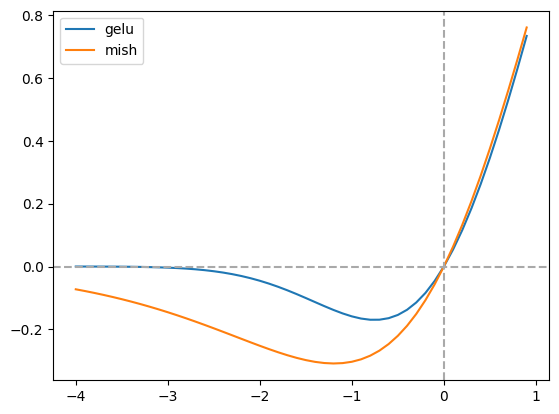

In [24]:
# Plotting postive and negative inputs against their outputs
gelu_vals = []
mish_vals = []
abscissa = np.arange(-4, 1, 0.1)
for val in abscissa:
  gelu_vals.append(gelu(tf.cast(val, tf.float32)).numpy())
  mish_vals.append(mish(tf.cast(val, tf.float32)).numpy())

plt.plot(abscissa, gelu_vals, label='gelu')
plt.plot(abscissa, mish_vals, label='mish')
plt.axvline(x=0.0, linestyle='--', color='darkgray')
plt.axhline(y=0.0, linestyle='--', color='darkgray')
plt.legend()
plt.show()


---

## 7i. Implementing model on Kaggle Challenge

Kaggle competition: Amazon.com - Employee Access Challenge [here](https://www.kaggle.com/c/amazon-employee-access-challenge)

Goal is to predict whether an Amazon employee should be given access to a specific resource based on their role and activies. Result should return the likelihood

Challenging because of high cardinality variables, used as a benchmark for gradient boosting algorithms. 

__How the model works__

1. Define an input for each feature - size is based on the cardinality of the feature
2. Each feature will have a unique embedding layer where it will be passed to
3. Output is then reduced through a heuristic to a logrithm of the input size
4. Output is passed to a spatial dropout that will blank out entire columns of the matrix returned by the embedding layer
5. Flattened results are concatenated into a single layer
6. Passed through 2 dense layers with dropout
7. Sigmoid activation function for likelihood calculation

Architecture only works with categorical data. **Continued pg 332

In [25]:
import tensorflow as tf
import tensorflow.keras as keras
import pandas as pd
from catboost.datasets import amazon

# Sequential-based data generators may trigger some errors, so disable it
tf.compat.v1.disable_eager_execution()

# Get data
X, Xt = amazon()
y = X["ACTION"].apply(lambda x: 1 if x==1 else 0).values
X.drop(["ACTION"], axis=1, inplace=True)
X

,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,42680,5905,117929,117930,119569,119323,123932,19793,119325
...,...,...,...,...,...,...,...,...,...
32764,23497,16971,117961,118300,119993,118321,240983,290919,118322
32765,25139,311198,91261,118026,122392,121143,173805,249618,121145
32766,34924,28805,117961,118327,120299,124922,152038,118612,124924
32767,80574,55643,118256,118257,117945,280788,280788,292795,119082


In [26]:
# High cardinality categorical variables - include input and embedding layer
#		- define single input layer
# 	- multiple embedding layers for each input variable

def dnn(categorical_variables, categorical_counts,
        feature_selection_dropout=0.2, categorical_dropout=0.1,
        first_dense = 256, second_dense = 256, dense_dropout = 0.2, 
        activation_type=gelu):
    
    categorical_inputs = []
    categorical_embeddings = []
    
    for category in categorical_variables:
        categorical_inputs.append(keras.layers.Input(shape=[1], 
                                                     name=category))
        category_counts = categorical_counts[category]
        categorical_embeddings.append(
            keras.layers.Embedding(category_counts+1, 
                      int(np.log1p(category_counts)+1), 
                      name = category + "_embed")(categorical_inputs[-1]))
    
    def flatten_dropout(x, categorical_dropout):
        return keras.layers.Flatten()(keras.layers.SpatialDropout1D(categorical_dropout)(x))
    
    categorical_logits = [flatten_dropout(cat_emb, categorical_dropout) for cat_emb in categorical_embeddings]
    categorical_concat = keras.layers.Concatenate(name = "categorical_concat")(categorical_logits)

    x = keras.layers.Dense(first_dense, activation=activation_type)(categorical_concat)
    x = keras.layers.Dropout(dense_dropout)(x)  
    x = keras.layers.Dense(second_dense, activation=activation_type)(x)
    x = keras.layers.Dropout(dense_dropout)(x)
    output = keras.layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(categorical_inputs, output)
    
    return model

In [27]:
from sklearn.metrics import average_precision_score, roc_auc_score

def mAP(y_true, y_pred):
    return tf.py_function(average_precision_score, (y_true, y_pred), tf.double)

def auc(y_true, y_pred):
    try:
        return tf.py_function(roc_auc_score, (y_true, y_pred), tf.double)
    except: 
        return 0.5

def compile_model(model, loss, metrics, optimizer):
    model.compile(loss=loss, metrics=metrics, optimizer=optimizer)
    return model

def plot_keras_history(history, measures):
    """
    history: Keras training history
    measures = list of names of measures
    """
    rows = len(measures) // 2 + len(measures) % 2
    fig, panels = plt.subplots(rows, 2, figsize=(15, 5))
    plt.subplots_adjust(top = 0.99, bottom=0.01, hspace=0.4, wspace=0.2)
    try:
        panels = [item for sublist in panels for item in sublist]
    except:
        pass
    for k, measure in enumerate(measures):
        panel = panels[k]
        panel.set_title(measure + ' history')
        panel.plot(history.epoch, history.history[measure], label="Train "+measure)
        panel.plot(history.epoch, history.history["val_"+measure], label="Validation "+measure)
        panel.set(xlabel='epochs', ylabel=measure)
        panel.legend()
        
    plt.show(fig)

Epoch 1/30


c:\Users\Martin Ho\Languages\python38\lib\site-packages\keras\engine\training_v1.py:2332: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


43/43 - 5s - loss: 0.6812 - auc: 0.4924 - mAP: 0.9411 - val_loss: 0.6656 - val_auc: 0.5091 - val_mAP: 0.9441 - 5s/epoch - 123ms/step
Epoch 2/30
43/43 - 2s - loss: 0.6483 - auc: 0.5310 - mAP: 0.9468 - val_loss: 0.6268 - val_auc: 0.5404 - val_mAP: 0.9483 - 2s/epoch - 39ms/step
Epoch 3/30
43/43 - 2s - loss: 0.6001 - auc: 0.5534 - mAP: 0.9504 - val_loss: 0.5665 - val_auc: 0.5662 - val_mAP: 0.9517 - 2s/epoch - 37ms/step
Epoch 4/30
43/43 - 2s - loss: 0.5259 - auc: 0.5928 - mAP: 0.9560 - val_loss: 0.4788 - val_auc: 0.5873 - val_mAP: 0.9549 - 2s/epoch - 37ms/step
Epoch 5/30
43/43 - 2s - loss: 0.4277 - auc: 0.6244 - mAP: 0.9596 - val_loss: 0.3756 - val_auc: 0.6096 - val_mAP: 0.9584 - 2s/epoch - 36ms/step
Epoch 6/30
43/43 - 2s - loss: 0.3291 - auc: 0.6536 - mAP: 0.9639 - val_loss: 0.2886 - val_auc: 0.6342 - val_mAP: 0.9621 - 2s/epoch - 40ms/step
Epoch 7/30
43/43 - 1s - loss: 0.2581 - auc: 0.6959 - mAP: 0.9689 - val_loss: 0.2384 - val_auc: 0.6617 - val_mAP: 0.9658 - 1s/epoch - 34ms/step
Epoch 8/3

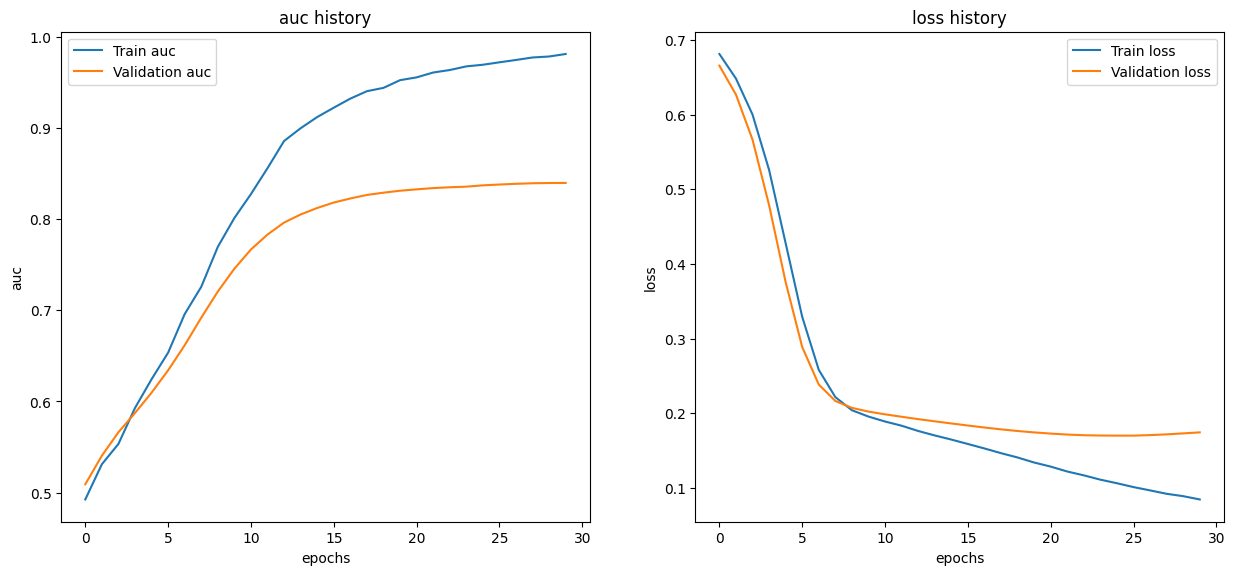

c:\Users\Martin Ho\Languages\python38\lib\site-packages\keras\engine\training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Epoch 1/30


c:\Users\Martin Ho\Languages\python38\lib\site-packages\keras\engine\training_v1.py:2332: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


43/43 - 5s - loss: 0.6826 - auc: 0.5316 - mAP: 0.9459 - val_loss: 0.6682 - val_auc: 0.5134 - val_mAP: 0.9442 - 5s/epoch - 107ms/step
Epoch 2/30
43/43 - 2s - loss: 0.6515 - auc: 0.5593 - mAP: 0.9513 - val_loss: 0.6304 - val_auc: 0.5196 - val_mAP: 0.9456 - 2s/epoch - 38ms/step
Epoch 3/30
43/43 - 2s - loss: 0.6036 - auc: 0.5717 - mAP: 0.9526 - val_loss: 0.5697 - val_auc: 0.5336 - val_mAP: 0.9484 - 2s/epoch - 39ms/step
Epoch 4/30
43/43 - 2s - loss: 0.5287 - auc: 0.5838 - mAP: 0.9548 - val_loss: 0.4805 - val_auc: 0.5537 - val_mAP: 0.9520 - 2s/epoch - 41ms/step
Epoch 5/30
43/43 - 2s - loss: 0.4301 - auc: 0.6145 - mAP: 0.9582 - val_loss: 0.3766 - val_auc: 0.5768 - val_mAP: 0.9557 - 2s/epoch - 40ms/step
Epoch 6/30
43/43 - 2s - loss: 0.3311 - auc: 0.6423 - mAP: 0.9632 - val_loss: 0.2894 - val_auc: 0.6017 - val_mAP: 0.9592 - 2s/epoch - 45ms/step
Epoch 7/30
43/43 - 2s - loss: 0.2611 - auc: 0.6676 - mAP: 0.9659 - val_loss: 0.2395 - val_auc: 0.6301 - val_mAP: 0.9630 - 2s/epoch - 37ms/step
Epoch 8/3

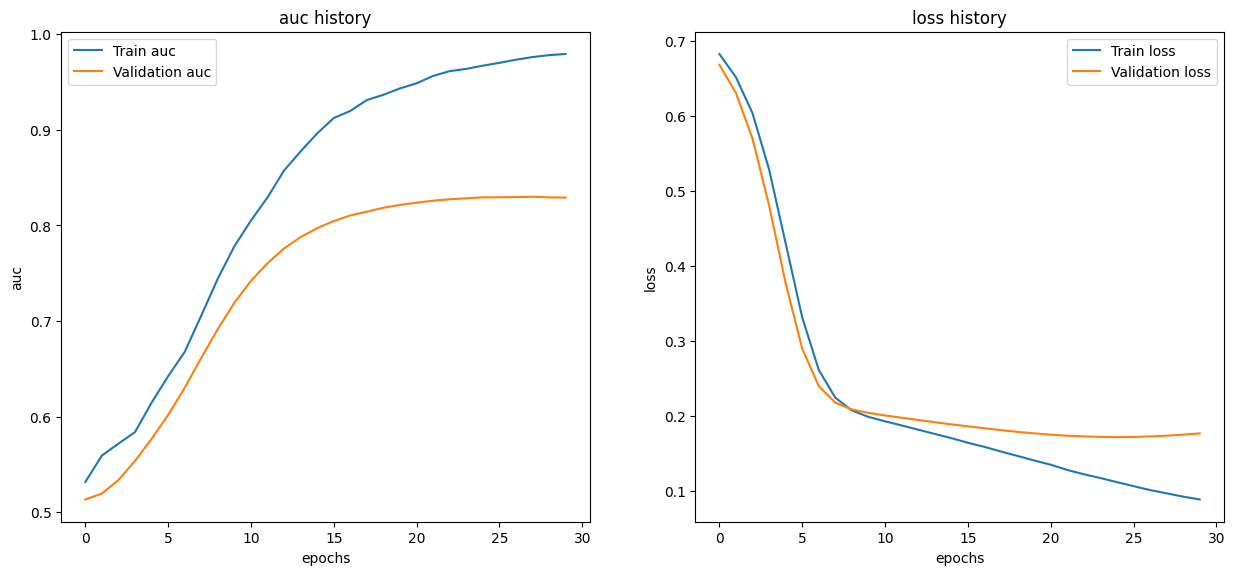

c:\Users\Martin Ho\Languages\python38\lib\site-packages\keras\engine\training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Epoch 1/30


c:\Users\Martin Ho\Languages\python38\lib\site-packages\keras\engine\training_v1.py:2332: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


43/43 - 6s - loss: 0.6787 - auc: 0.4964 - mAP: 0.9406 - val_loss: 0.6646 - val_auc: 0.5255 - val_mAP: 0.9422 - 6s/epoch - 128ms/step
Epoch 2/30
43/43 - 2s - loss: 0.6470 - auc: 0.5171 - mAP: 0.9442 - val_loss: 0.6259 - val_auc: 0.5404 - val_mAP: 0.9435 - 2s/epoch - 38ms/step
Epoch 3/30
43/43 - 2s - loss: 0.5985 - auc: 0.5380 - mAP: 0.9464 - val_loss: 0.5650 - val_auc: 0.5518 - val_mAP: 0.9451 - 2s/epoch - 41ms/step
Epoch 4/30
43/43 - 2s - loss: 0.5252 - auc: 0.5612 - mAP: 0.9498 - val_loss: 0.4805 - val_auc: 0.5664 - val_mAP: 0.9467 - 2s/epoch - 39ms/step
Epoch 5/30
43/43 - 2s - loss: 0.4326 - auc: 0.5828 - mAP: 0.9536 - val_loss: 0.3845 - val_auc: 0.5811 - val_mAP: 0.9492 - 2s/epoch - 38ms/step
Epoch 6/30
43/43 - 2s - loss: 0.3415 - auc: 0.6105 - mAP: 0.9559 - val_loss: 0.3036 - val_auc: 0.6000 - val_mAP: 0.9525 - 2s/epoch - 39ms/step
Epoch 7/30
43/43 - 2s - loss: 0.2740 - auc: 0.6386 - mAP: 0.9607 - val_loss: 0.2530 - val_auc: 0.6212 - val_mAP: 0.9562 - 2s/epoch - 40ms/step
Epoch 8/3

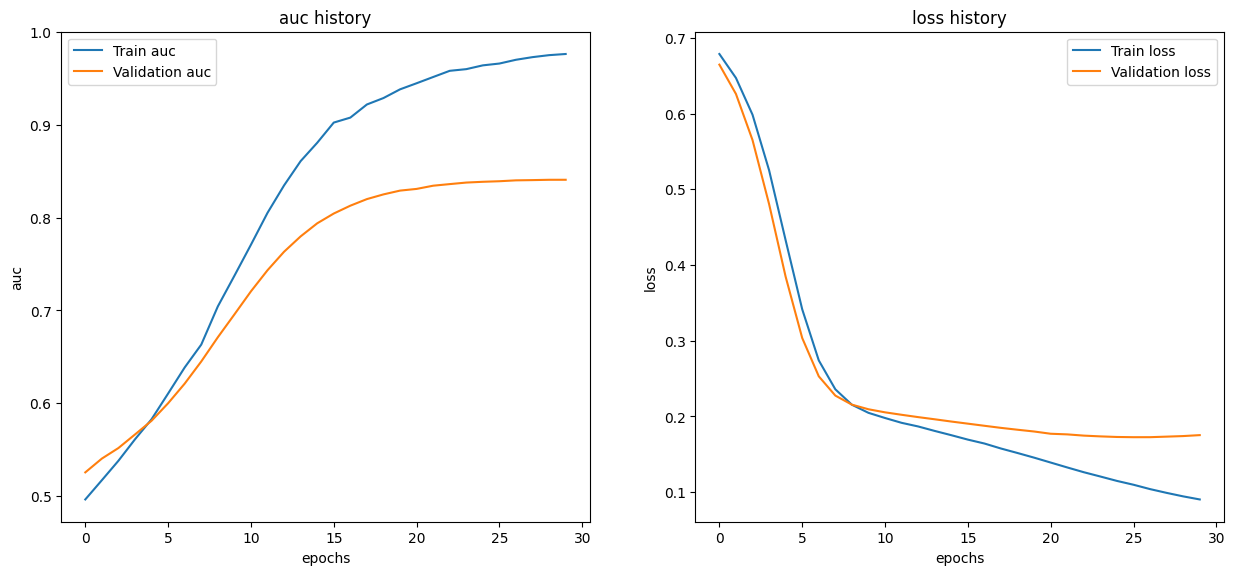

c:\Users\Martin Ho\Languages\python38\lib\site-packages\keras\engine\training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


mean cv roc auc 0.838
mean cv average precision 0.985


In [28]:
from sklearn.model_selection import StratifiedKFold

SEED = 0
FOLDS = 3
BATCH_SIZE = 512

skf = StratifiedKFold(n_splits=FOLDS, 
                      shuffle=True, 
                      random_state=SEED)

roc_auc = list()
average_precision = list()
categorical_variables = X.columns.to_list()

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    
    tt = TabularTransformer(highcat = categorical_variables)

    tt.fit(X.iloc[train_idx])   
    categorical_levels = tt.vocabulary
    
    model = dnn(categorical_variables,
                categorical_levels, 
                feature_selection_dropout=0.1,
                categorical_dropout=0.1,
                first_dense=64,
                second_dense=64,
                dense_dropout=0.1,
                activation_type=mish)
    
    model = compile_model(model, 
                          keras.losses.binary_crossentropy, 
                          [auc, mAP], 
                          tf.keras.optimizers.Adam(learning_rate=0.0001))
    
    train_batch = DataGenerator(X.iloc[train_idx], 
                                y[train_idx],
                                tabular_transformer=tt,
                                batch_size=BATCH_SIZE,
                                shuffle=True)
    
    val_X, val_y = tt.transform(X.iloc[test_idx]), y[test_idx]
    
    history = model.fit(train_batch,
                        validation_data=(val_X, val_y),
                        epochs=30,
                        class_weight=[1.0, (np.sum(y==0) / np.sum(y==1))],
                        verbose=2)
    
    print("\nFOLD %i" % fold)
    plot_keras_history(history, measures=['auc', 'loss'])
    
    preds = model.predict(val_X, verbose=0, batch_size=1024).flatten()

    roc_auc.append(roc_auc_score(y_true=val_y, y_score=preds))
    average_precision.append(average_precision_score(y_true=val_y, y_score=preds))
    
print(f"mean cv roc auc {np.mean(roc_auc):0.3f}")
print(f"mean cv average precision {np.mean(average_precision):0.3f}")

__Summary__

All the folds have a similar trajectory, with a significant decoupling of train and validation curves after 5 epochs and a widening gap after 15 epochs, which suggests some overfitting might be occurring.

Suggestion to change the DNN architecture or adjust some hyperparameters like learning rate or the optimizing algorithm. Cross-validation through K-folds stratified sampling will ensure a fair comparison between the adjustments